# Evaluasi dan perbandingan model AquaSmart

Tugas Mandiri Hari 2 (MODUL_PRAKTIKUM2, Bagian 1: Machine Learning dan Deep Learning). Notebook ini
melanjutkan `02_baseline.ipynb`: fitur, label proksi, dan pembagian latih/uji sama persis dengan
Hari 1, dan pembanding utamanya tetap aturan ambang non-AI.

Jalankan dari akar repository atau folder `notebooks`. Notebook membaca `fitur_dan_target.csv` dan
`data_bersih_5menit.csv` hasil Hari 1 di `01_AquaSmart/08_Sistem-Cerdas/tugas_mandiri/`, dan batas
pH/suhu langsung dari `ThresholdRules.php` lewat `mandiri.py`. Dataset mentah, kunci API, dan server
PHP tidak diperlukan. Model final disimpan ke `01_AquaSmart/08_Sistem-Cerdas/tugas_mandiri_hari2/`.

In [1]:
from pathlib import Path
import re
import sys

import matplotlib
import numpy
import pandas
import sklearn

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / '01_AquaSmart/08_Sistem-Cerdas/mandiri.py').exists())
sys.path.insert(0, str(ROOT / '01_AquaSmart/08_Sistem-Cerdas'))
import mandiri

HARI1 = mandiri.OUT
HARI2 = mandiri.HERE / 'tugas_mandiri_hari2'
HARI2.mkdir(exist_ok=True)
# mandiri.RULES holds the four limits; the contract version labels the saved model.
php = (ROOT / '01_AquaSmart/01_Aplikasi-Web/server/src/ThresholdRules.php').read_text(encoding='utf-8')
ATURAN = {**mandiri.RULES, 'VERSION': re.search(r"const VERSION = '([^']+)';", php)[1]}

print(f'Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | '
      f'pandas {pandas.__version__} | numpy {numpy.__version__} | matplotlib {matplotlib.__version__}')

Python 3.12.13 | scikit-learn 1.9.1 | pandas 3.0.6 | numpy 2.5.3 | matplotlib 3.11.2


## Soal 1 Bagian, metrik, dan pembanding

*Jawaban:*

**a. Bagian yang dikerjakan: Bagian 1 (Machine Learning dan Deep Learning).**

Project tim adalah AquaSmart AIoT, pemantauan kualitas air kolam ikan. Model dilatih sendiri dari
data sensor kolam (pH, TDS, suhu) yang sudah dibersihkan dan diberi fitur pada Hari 1, bukan
memakai LLM yang sudah jadi, sehingga Bagian 2 tidak sesuai. Jenis tugasnya classification: dari
riwayat satu jam terakhir, model menebak apakah interval 5 menit berikutnya berstatus **Luar**
ambang (kelas 1: pH atau suhu di luar batas aplikasi) atau **Dalam** ambang (kelas 0). Batasnya
diambil dari `ThresholdRules.php` aplikasi AquaSmart (`threshold-rules-v2`). Artinya label ini
adalah label proksi dari aturan aplikasi, bukan penilaian ahli atau kondisi kesehatan ikan.

**b. Metrik utama: macro F1.**

Kelas Luar adalah mayoritas (7.754 dari 8.525 interval latih, sekitar 91%). F1 kelas Luar saja
akan tetap tinggi walaupun model selalu menebak Luar; pada Hari 1 dummy mayoritas mendapat recall
alarm 1,000 tetapi macro F1 hanya 0,469. Macro F1 merata-ratakan F1 kelas Dalam dan kelas Luar
dengan bobot sama, sehingga kedua jenis kesalahan ikut terhitung. Dua metrik pendukung:

- **Recall Luar**: dari semua interval yang benar-benar di luar ambang, berapa yang ditebak Luar.
  Kasus yang terlewat (FN) berbahaya bagi ikan.
- **Recall Dalam**: dari semua interval yang aman, berapa yang tidak dibunyikan alarm. Nilai rendah
  berarti banyak alarm palsu (FP); alarm yang terlalu sering akhirnya diabaikan pembudidaya.

**Pembanding:** model Random Forest Hari 1, aturan ambang non-AI (status interval terakhir dianggap
berlanjut; pada Hari 1 aturan ini mengungguli Random Forest), dan dummy kelas mayoritas. Karena data
berurutan waktu, validasi memakai `TimeSeriesSplit` 5 fold dengan jeda 12 interval (1 jam) seperti
Hari 1, bukan `cv=5` acak yang akan mencampur masa depan ke data latih. Data uji (20% periode
terakhir, 7 sampai 22 Maret 2023) baru dibuka sekali di akhir Soal 3.

## Soal 2 Evaluasi dan perbandingan

### 2.1 Data AquaSmart hasil Hari 1

Dua berkas hasil Tugas Mandiri Hari 1 dibaca tanpa diubah dari `01_AquaSmart/08_Sistem-Cerdas/tugas_mandiri/`:

- `fitur_dan_target.csv`: 12 fitur riwayat (lag 1, lag 2, rata-rata dan simpangan baku 12 interval
  untuk pH, TDS, suhu) dan `target_proxy` (1 = Luar ambang, 0 = Dalam ambang).
- `data_bersih_5menit.csv`: median sensor per 5 menit, dipakai untuk membaca kesalahan di Soal 3.

Batas pH dan suhu dibaca dari `ThresholdRules.php` lewat `mandiri.py`, jadi angka ambang tidak ditulis
ulang di notebook.

Pembagian data sama persis dengan Hari 1: 80% periode awal untuk latih, 20% akhir untuk uji, dan
satu jam sebelum awal uji dibuang agar jendela fitur latih tidak menyentuh periode uji.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, recall_score, make_scorer,
                             ConfusionMatrixDisplay, classification_report)

aq = pd.read_csv(HARI1 / 'fitur_dan_target.csv',
                 parse_dates=['timestamp'], index_col='timestamp')
sensor = pd.read_csv(HARI1 / 'data_bersih_5menit.csv',
                     parse_dates=['timestamp'], index_col='timestamp')

fitur_aq = [c for c in aq.columns if c != 'target_proxy']
X_aq, y_aq = aq[fitur_aq], aq['target_proxy']

batas = X_aq.index[int(len(X_aq) * 0.8)]
X_latih = X_aq[X_aq.index < batas - pd.Timedelta(minutes=60)]
y_latih = y_aq.loc[X_latih.index]
X_uji = X_aq[X_aq.index >= batas]
y_uji = y_aq.loc[X_uji.index]

print(f"Aturan ambang {ATURAN['VERSION']}: pH {ATURAN['PH_MIN']}-{ATURAN['PH_MAX']}, "
      f"suhu {ATURAN['TEMP_MIN']}-{ATURAN['TEMP_MAX']} C")
print('Jumlah fitur:', len(fitur_aq))
print('Data latih:', X_latih.shape, '|', X_latih.index.min(), 'sampai', X_latih.index.max())
print('Data uji  :', X_uji.shape, '|', X_uji.index.min(), 'sampai', X_uji.index.max())
print('Proporsi kelas Luar di data latih:', round(y_latih.mean(), 3))

Aturan ambang threshold-rules-v2: pH 6.5-8.5, suhu 25.0-30.0 C
Jumlah fitur: 12
Data latih: (8525, 12) | 2023-01-26 12:05:00 sampai 2023-03-07 20:35:00
Data uji  : (2135, 12) | 2023-03-07 21:40:00 sampai 2023-03-22 17:50:00
Proporsi kelas Luar di data latih: 0.91


### 2.2 Confusion matrix baseline Hari 1 (seperti langkah 1.2)

Model Hari 1 dibuat ulang dengan pengaturan dan `random_state` yang sama, seperti langkah 1.0
praktikum. Aturan ambang non-AI juga ditampilkan karena menjadi pembanding utama di Hari 1.
`buat_pipe_aq()` adalah alur Hari 1 (imputer median + scaler) yang dipakai ulang untuk setiap model.

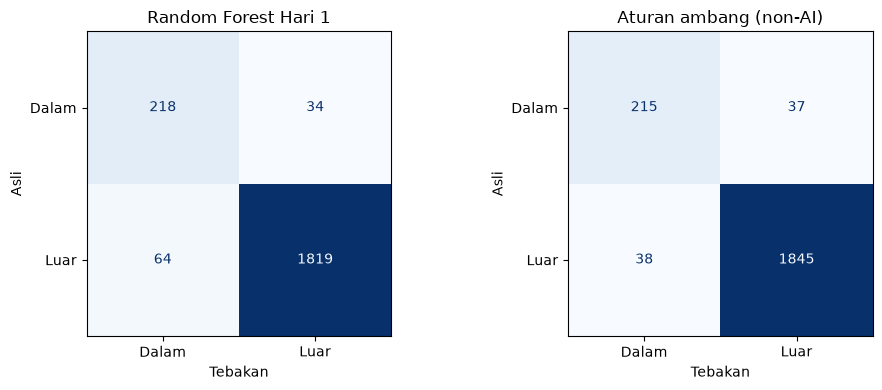

Random Forest Hari 1 | macro F1 = 0.8951
              precision    recall  f1-score   support

       Dalam      0.773     0.865     0.816       252
        Luar      0.982     0.966     0.974      1883

    accuracy                          0.954      2135
   macro avg      0.877     0.916     0.895      2135
weighted avg      0.957     0.954     0.955      2135

Aturan ambang (non-AI) | macro F1 = 0.9158
              precision    recall  f1-score   support

       Dalam      0.850     0.853     0.851       252
        Luar      0.980     0.980     0.980      1883

    accuracy                          0.965      2135
   macro avg      0.915     0.916     0.916      2135
weighted avg      0.965     0.965     0.965      2135



In [3]:
def buat_pipe_aq(model):
    """Alur Hari 1 AquaSmart: imputer median (dengan penanda data hilang) + scaler + model."""
    prep = ColumnTransformer([('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', StandardScaler())]), fitur_aq)])
    return Pipeline([('prep', prep), ('model', model)])

def aturan_ambang(X):
    """Baseline non-AI Hari 1: status interval terakhir dianggap berlanjut."""
    dalam = (X['ph_lag1'].between(ATURAN['PH_MIN'], ATURAN['PH_MAX'])
             & X['temp_lag1'].between(ATURAN['TEMP_MIN'], ATURAN['TEMP_MAX']))
    return (~dalam).astype(int).to_numpy()

def skor(y_asli, y_tebak):
    """Macro F1 memakai kedua label seperti Hari 1; recall bernilai NaN bila kelasnya tidak ada."""
    return {'Macro F1': f1_score(y_asli, y_tebak, labels=[0, 1], average='macro',
                                 zero_division=0),
            'Recall Luar': recall_score(y_asli, y_tebak, pos_label=1, zero_division=np.nan),
            'Recall Dalam': recall_score(y_asli, y_tebak, pos_label=0, zero_division=np.nan)}

rf_hari1 = buat_pipe_aq(RandomForestClassifier(
    n_estimators=160, max_depth=10, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=2))
rf_hari1.fit(X_latih, y_latih)

pred_hari1 = {'Random Forest Hari 1': rf_hari1.predict(X_uji),
              'Aturan ambang (non-AI)': aturan_ambang(X_uji)}

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, (nama, pred) in zip(ax, pred_hari1.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_uji, pred, display_labels=['Dalam', 'Luar'], cmap='Blues', ax=a, colorbar=False)
    a.set_title(nama)
    a.set_xlabel('Tebakan'); a.set_ylabel('Asli')
plt.tight_layout()
plt.show()

for nama, pred in pred_hari1.items():
    print(nama, '| macro F1 =', round(skor(y_uji, pred)['Macro F1'], 4))
    print(classification_report(y_uji, pred, target_names=['Dalam', 'Luar'], digits=3))

### 2.3 Membandingkan model dengan cross-validation (seperti langkah 1.4)

`cv=5` pada praktikum mengacak urutan baris. Data AquaSmart berurutan waktu, jadi dipakai
`TimeSeriesSplit(n_splits=5, gap=12)`: model selalu dilatih pada periode sebelumnya dan divalidasi
pada periode sesudahnya, dengan jeda 12 interval (1 jam) seperti Hari 1. Semua model memakai alur
yang sama; hanya algoritmanya yang diganti.

In [4]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

tscv = TimeSeriesSplit(n_splits=5, gap=12)
for k, (tr, va) in enumerate(tscv.split(X_latih), 1):
    print(f'Fold {k}: latih {len(tr):>4} baris, validasi {len(va)} baris '
          f'({X_latih.index[va[0]]:%d %b} - {X_latih.index[va[-1]]:%d %b}), '
          f'interval Dalam di validasi = {(y_latih.iloc[va] == 0).sum()}')

def evaluasi_cv(model):
    """Skor tiap fold validasi. model=None berarti aturan ambang (tidak perlu dilatih)."""
    baris = []
    for tr, va in tscv.split(X_latih):
        if model is None:
            pred = aturan_ambang(X_latih.iloc[va])
        else:
            m = clone(model).fit(X_latih.iloc[tr], y_latih.iloc[tr])
            pred = m.predict(X_latih.iloc[va])
        baris.append(skor(y_latih.iloc[va], pred))
    return pd.DataFrame(baris)

def ringkas(nilai):
    """'rata-rata ± simpangan' seperti modul; fold yang nilainya NaN dilewati."""
    return f'{np.nanmean(nilai):.3f} ± {np.nanstd(nilai):.3f}'

def tabel_cv(hasil):
    return pd.DataFrame([{'Model': nama,
                          'Macro F1 (5 fold)': ringkas(s['Macro F1']),
                          'Macro F1 (fold 1-4)': ringkas(s['Macro F1'].iloc[:4]),
                          'Recall Luar': ringkas(s['Recall Luar']),
                          'Recall Dalam': ringkas(s['Recall Dalam'])}
                         for nama, s in hasil.items()])

kandidat_aq = {
    'Dummy mayoritas': buat_pipe_aq(DummyClassifier(strategy='most_frequent')),
    'Aturan ambang (non-AI)': None,
    'Logistic Regression': buat_pipe_aq(LogisticRegression(max_iter=1000,
                                                           class_weight='balanced')),
    'Random Forest Hari 1': rf_hari1,
    'MLP (16, 8)': buat_pipe_aq(MLPClassifier(hidden_layer_sizes=(16, 8), early_stopping=True,
                                              max_iter=500, random_state=42)),
}
hasil_cv = {nama: evaluasi_cv(model) for nama, model in kandidat_aq.items()}
print()
print(tabel_cv(hasil_cv).to_string(index=False))

Fold 1: latih 1413 baris, validasi 1420 baris (03 Feb - 08 Feb), interval Dalam di validasi = 267
Fold 2: latih 2833 baris, validasi 1420 baris (08 Feb - 14 Feb), interval Dalam di validasi = 73
Fold 3: latih 4253 baris, validasi 1420 baris (14 Feb - 20 Feb), interval Dalam di validasi = 139
Fold 4: latih 5673 baris, validasi 1420 baris (20 Feb - 28 Feb), interval Dalam di validasi = 34
Fold 5: latih 7093 baris, validasi 1420 baris (28 Feb - 07 Mar), interval Dalam di validasi = 0



                 Model Macro F1 (5 fold) Macro F1 (fold 1-4)   Recall Luar  Recall Dalam
       Dummy mayoritas     0.481 ± 0.018       0.476 ± 0.017 1.000 ± 0.000 0.000 ± 0.000
Aturan ambang (non-AI)     0.836 ± 0.176       0.920 ± 0.058 0.989 ± 0.012 0.856 ± 0.101
   Logistic Regression     0.715 ± 0.168       0.782 ± 0.115 0.915 ± 0.065 0.793 ± 0.153
  Random Forest Hari 1     0.798 ± 0.184       0.885 ± 0.065 0.924 ± 0.069 0.959 ± 0.047
           MLP (16, 8)     0.636 ± 0.161       0.674 ± 0.159 0.977 ± 0.022 0.371 ± 0.325


### 2.4 Tuning Random Forest dengan GridSearchCV (seperti langkah 1.5)

Skor yang dioptimalkan adalah macro F1 (metrik utama Soal 1), dengan fold waktu yang sama.
`max_depth=10` ikut dicoba karena itu pengaturan Hari 1.

In [5]:
from sklearn.model_selection import GridSearchCV

macro_f1 = make_scorer(f1_score, labels=[0, 1], average='macro', zero_division=0)
parameter = {'model__n_estimators': [100, 300],
             'model__max_depth': [3, 6, 10, None]}

grid_aq = GridSearchCV(
    buat_pipe_aq(RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)),
    parameter, cv=tscv, scoring=macro_f1, return_train_score=True)
grid_aq.fit(X_latih, y_latih)

print('Parameter terbaik    :', grid_aq.best_params_)
print(f'Macro F1 terbaik (CV): {grid_aq.best_score_:.3f}')
tabel_grid = pd.DataFrame(grid_aq.cv_results_)[
    ['params', 'mean_train_score', 'mean_test_score', 'std_test_score']]
print(tabel_grid.sort_values('mean_test_score', ascending=False)
      .round(3).to_string(index=False))

Parameter terbaik    : {'model__max_depth': 10, 'model__n_estimators': 300}
Macro F1 terbaik (CV): 0.813
                                                params  mean_train_score  mean_test_score  std_test_score
  {'model__max_depth': 10, 'model__n_estimators': 300}             0.950            0.813           0.169
  {'model__max_depth': 10, 'model__n_estimators': 100}             0.952            0.812           0.162
   {'model__max_depth': 6, 'model__n_estimators': 300}             0.924            0.801           0.185
   {'model__max_depth': 6, 'model__n_estimators': 100}             0.924            0.801           0.185
{'model__max_depth': None, 'model__n_estimators': 300}             0.988            0.800           0.159
   {'model__max_depth': 3, 'model__n_estimators': 100}             0.904            0.799           0.185
   {'model__max_depth': 3, 'model__n_estimators': 300}             0.905            0.794           0.182
{'model__max_depth': None, 'model__n_estimators

### 2.5 Tabel perbandingan

Semua angka dari data latih (cross-validation); data uji belum dibuka. Kolom "fold 1-4" ditampilkan
karena fold 5 tidak memiliki interval Dalam, sehingga macro F1 di fold itu paling tinggi 0,5 untuk
model apa pun. Recall Dalam juga hanya dihitung dari fold yang memiliki kelas Dalam.

                 Model Macro F1 (5 fold) Macro F1 (fold 1-4)   Recall Luar  Recall Dalam
       Dummy mayoritas     0.481 ± 0.018       0.476 ± 0.017 1.000 ± 0.000 0.000 ± 0.000
Aturan ambang (non-AI)     0.836 ± 0.176       0.920 ± 0.058 0.989 ± 0.012 0.856 ± 0.101
   Logistic Regression     0.715 ± 0.168       0.782 ± 0.115 0.915 ± 0.065 0.793 ± 0.153
  Random Forest Hari 1     0.798 ± 0.184       0.885 ± 0.065 0.924 ± 0.069 0.959 ± 0.047
           MLP (16, 8)     0.636 ± 0.161       0.674 ± 0.159 0.977 ± 0.022 0.371 ± 0.325
       RF hasil tuning     0.813 ± 0.169       0.895 ± 0.044 0.959 ± 0.032 0.901 ± 0.078

Macro F1 per fold:
                        Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
Dummy mayoritas          0.448   0.487   0.474   0.494   0.500
Aturan ambang (non-AI)   0.968   0.904   0.833   0.977   0.500
Logistic Regression      0.856   0.913   0.744   0.613   0.451
Random Forest Hari 1     0.939   0.914   0.773   0.914   0.450
MLP (16, 8)              0.448   0.880   0

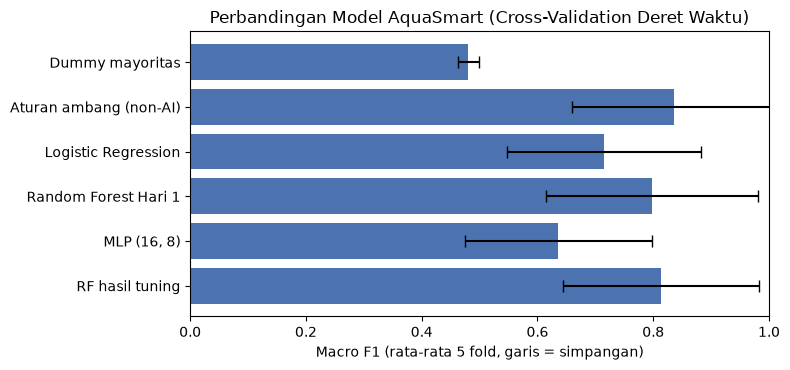

In [6]:
hasil_cv['RF hasil tuning'] = evaluasi_cv(grid_aq.best_estimator_)
tabel_perbandingan = tabel_cv(hasil_cv)
print(tabel_perbandingan.to_string(index=False))

print('\nMacro F1 per fold:')
per_fold = pd.DataFrame({nama: s['Macro F1'].to_numpy() for nama, s in hasil_cv.items()},
                        index=[f'Fold {k}' for k in range(1, 6)]).T
print(per_fold.round(3).to_string())

rata = [np.mean(s['Macro F1']) for s in hasil_cv.values()]
simpang = [np.std(s['Macro F1']) for s in hasil_cv.values()]
plt.figure(figsize=(8, 3.8))
plt.barh(list(hasil_cv), rata, xerr=simpang, color='#4C72B0', capsize=4)
plt.gca().invert_yaxis()
plt.xlabel('Macro F1 (rata-rata 5 fold, garis = simpangan)')
plt.title('Perbandingan Model AquaSmart (Cross-Validation Deret Waktu)')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

**Model/konfigurasi yang dipilih dan alasannya (dari cross-validation, sebelum data uji dibuka):**

- Di antara model ML, **Random Forest hasil tuning** (`max_depth=10`, `n_estimators=300`,
  `class_weight='balanced'`) mendapat macro F1 tertinggi: 0,813 ± 0,169 (fold 1-4: 0,895 ± 0,044),
  dengan recall Luar 0,959 dan recall Dalam 0,901. Model ini dibawa ke Soal 3 sebagai model ML final.
- Tuning hanya menaikkan macro F1 dari 0,798 (RF Hari 1) ke 0,813. Kenaikan ini lebih kecil dari
  simpangannya, jadi perbaikannya belum bisa disebut nyata.
- **Aturan ambang non-AI tetap paling tinggi**: 0,836 ± 0,176 (fold 1-4: 0,920 ± 0,058), recall
  Luar 0,989. Selisihnya dengan RF tuning (0,023) lebih kecil dari simpangan, jadi keduanya setara.
  Sesuai prinsip modul, bila setara pilih yang lebih sederhana: aturan tetap menjadi alarm utama
  aplikasi, sama dengan kesimpulan Hari 1.
- MLP paling rendah di antara model ML (0,636) karena tidak punya `class_weight`; recall Dalam
  hanya 0,371, artinya hampir semua interval ditebak Luar. Logistic Regression (0,715) di bawah model
  pohon, kemungkinan karena status Luar terjadi di kedua ujung (pH terlalu rendah atau terlalu
  tinggi, suhu terlalu rendah atau terlalu tinggi), pola yang tidak bisa dipisahkan satu garis lurus.
- Simpangan dihitung seperti `ringkas()` modul (`np.std`). Laporan Hari 1 memakai simpangan sampel
  (ddof=1), sehingga RF Hari 1 tertulis 0,7981 ± 0,2053; rata-ratanya sama.

## Soal 3 Keputusan dan pemeriksaan

### 3.1 Memilih threshold (seperti langkah 1.3)

Peluang Luar untuk setiap interval validasi dikumpulkan dari kelima fold. `cross_val_predict` tidak
bisa dipakai dengan `TimeSeriesSplit` karena bagian awal data latih tidak pernah menjadi validasi,
jadi peluangnya dikumpulkan manual. Data uji tetap disegel.

In [7]:
model_pilihan = grid_aq.best_estimator_

peluang_cv = pd.Series(np.nan, index=y_latih.index)
for tr, va in tscv.split(X_latih):
    m = clone(model_pilihan).fit(X_latih.iloc[tr], y_latih.iloc[tr])
    peluang_cv.iloc[va] = m.predict_proba(X_latih.iloc[va])[:, 1]
ada = peluang_cv.notna()
y_cv = y_latih[ada]

def baris_threshold(nama, pred):
    return {'Threshold': nama, **skor(y_cv, pred),
            'Luar terlewat (FN)': int(((pred == 0) & (y_cv == 1)).sum()),
            'Alarm palsu (FP)': int(((pred == 1) & (y_cv == 0)).sum())}

baris = [baris_threshold('aturan non-AI', aturan_ambang(X_latih[ada]))]
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    baris.append(baris_threshold(t, (peluang_cv[ada] >= t).astype(int).to_numpy()))

print('Interval validasi:', int(ada.sum()), '| Dalam:', int((y_cv == 0).sum()),
      '| Luar:', int((y_cv == 1).sum()))
print(pd.DataFrame(baris).round(3).to_string(index=False))

Interval validasi: 7100 | Dalam: 513 | Luar: 6587
    Threshold  Macro F1  Recall Luar  Recall Dalam  Luar terlewat (FN)  Alarm palsu (FP)
aturan non-AI     0.926        0.989         0.864                  72                70
          0.2     0.663        0.995         0.232                  32               394
          0.3     0.781        0.988         0.478                  77               268
          0.4     0.857        0.983         0.708                 114               150
          0.5     0.859        0.959         0.901                 269                51
          0.6     0.811        0.925         0.975                 497                13
          0.7     0.808        0.920         0.992                 526                 4
          0.8     0.803        0.917         0.994                 548                 3


**Alasan memilih threshold 0,4 (diputuskan dari tabel CV di atas, sebelum data uji dibuka):**
threshold 0,4 dan 0,5 memberi macro F1 hampir sama (0,857 dan 0,859). Pada 0,4, interval Luar yang
terlewat turun dari 269 menjadi 114, dengan alarm palsu naik dari 51 menjadi 150. Untuk kolam ikan,
kondisi buruk yang terlewat lebih berbahaya daripada alarm palsu, jadi 0,4 dipilih.

Catatan: pada tabel yang sama, aturan non-AI tetap lebih baik di kedua sisi (FN 72, FP 70, macro F1
0,926). Tidak ada threshold yang membuat Random Forest menyamai aturan.

In [8]:
THRESHOLD_AQ = 0.4   # alasan: sel teks di atas

### 3.2 Memeriksa overfitting (seperti langkah 1.6)

Decision Tree dengan kedalaman berbeda, fold waktu yang sama. `class_weight='balanced'` dipakai
seperti model lain karena kelas Dalam hanya sekitar 9%.

max_depth=1     F1 latih=0.873  F1 validasi=0.747  selisih=0.126


max_depth=2     F1 latih=0.908  F1 validasi=0.823  selisih=0.085


max_depth=3     F1 latih=0.919  F1 validasi=0.818  selisih=0.101

max_depth=5     F1 latih=0.931  F1 validasi=0.819  selisih=0.112
max_depth=8     F1 latih=0.947  F1 validasi=0.819  selisih=0.128


max_depth=12    F1 latih=0.967  F1 validasi=0.745  selisih=0.222


max_depth=None  F1 latih=1.000  F1 validasi=0.687  selisih=0.313


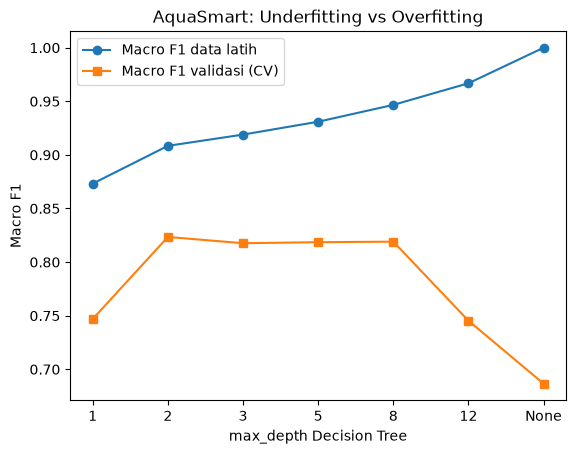

RF hasil tuning: macro F1 latih 0.950, validasi 0.813


In [9]:
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier

kedalaman = [1, 2, 3, 5, 8, 12, None]
f1_latih, f1_validasi = [], []
for d in kedalaman:
    cv = cross_validate(
        buat_pipe_aq(DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                            random_state=42)),
        X_latih, y_latih, cv=tscv, scoring=macro_f1, return_train_score=True)
    f1_latih.append(cv['train_score'].mean())
    f1_validasi.append(cv['test_score'].mean())
    print(f'max_depth={str(d):<5} F1 latih={f1_latih[-1]:.3f}  '
          f'F1 validasi={f1_validasi[-1]:.3f}  selisih={f1_latih[-1] - f1_validasi[-1]:.3f}')

label = [str(d) for d in kedalaman]
plt.plot(label, f1_latih, 'o-', label='Macro F1 data latih')
plt.plot(label, f1_validasi, 's-', label='Macro F1 validasi (CV)')
plt.xlabel('max_depth Decision Tree')
plt.ylabel('Macro F1')
plt.title('AquaSmart: Underfitting vs Overfitting')
plt.legend()
plt.show()

i = grid_aq.best_index_
print(f"RF hasil tuning: macro F1 latih {grid_aq.cv_results_['mean_train_score'][i]:.3f}, "
      f"validasi {grid_aq.cv_results_['mean_test_score'][i]:.3f}")

**Hasil pemeriksaan overfitting:** `max_depth=1` underfitting (validasi 0,747). `max_depth` 2 sampai
8 memberi validasi stabil sekitar 0,82 dengan selisih latih-validasi 0,085 sampai 0,128. Mulai
`max_depth=12` terjadi overfitting: skor latih naik (0,967; 1,000) tetapi validasi turun (0,745;
0,687), dengan selisih 0,222 dan 0,313.

RF hasil tuning punya selisih 0,137 (latih 0,950, validasi 0,813). Selisih ini tidak seluruhnya
hafalan: pohon paling sederhana (`max_depth=1`), yang tidak mampu menghafal, pun punya selisih 0,126.
Artinya sebagian besar selisih datang dari perbedaan kondisi antarperiode, karena setiap fold
validasi berada sesudah periode latihnya.

### 3.3 Model final dan uji sekali (seperti langkah 1.8)

Model hasil tuning dengan threshold pilihan dibandingkan dengan dua baseline Hari 1 pada data uji.
Data uji dibuka satu kali di sel ini; tidak ada pengaturan yang diubah sesudahnya.

Data uji: 2135 interval | Dalam: 252 | Luar: 1883
                   Model  Macro F1  Recall Luar  Recall Dalam  Luar terlewat (FN)  Alarm palsu (FP)
  Aturan ambang (non-AI)     0.916        0.980         0.853                  38                37
    Random Forest Hari 1     0.895        0.966         0.865                  64                34
RF tuning, threshold 0.4     0.716        0.986         0.349                  26               164


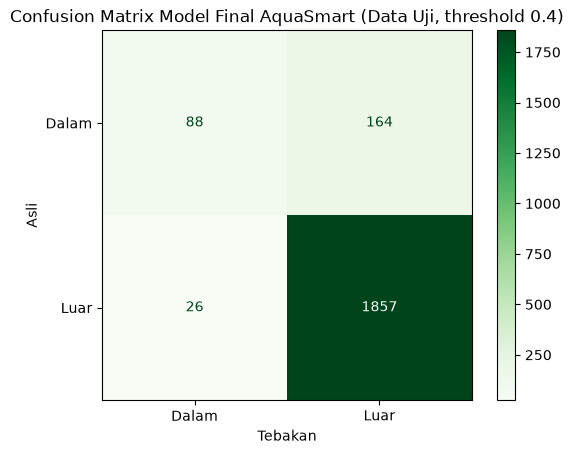

Model final dan threshold tersimpan di 01_AquaSmart/08_Sistem-Cerdas/tugas_mandiri_hari2/aquasmart_model_final_hari2.joblib


In [10]:
import joblib

model_final_aq = grid_aq.best_estimator_   # sudah dilatih ulang pada seluruh data latih
peluang_uji = model_final_aq.predict_proba(X_uji)[:, 1]
pred_final = (peluang_uji >= THRESHOLD_AQ).astype(int)

pred_uji = {'Aturan ambang (non-AI)': aturan_ambang(X_uji),
            'Random Forest Hari 1': rf_hari1.predict(X_uji),
            f'RF tuning, threshold {THRESHOLD_AQ}': pred_final}
hasil_uji = pd.DataFrame([{'Model': nama, **skor(y_uji, pred),
                           'Luar terlewat (FN)': int(((pred == 0) & (y_uji == 1)).sum()),
                           'Alarm palsu (FP)': int(((pred == 1) & (y_uji == 0)).sum())}
                          for nama, pred in pred_uji.items()])
print('Data uji:', len(y_uji), 'interval | Dalam:', int((y_uji == 0).sum()),
      '| Luar:', int((y_uji == 1).sum()))
print(hasil_uji.round(3).to_string(index=False))

ConfusionMatrixDisplay.from_predictions(
    y_uji, pred_final, display_labels=['Dalam', 'Luar'], cmap='Greens')
plt.title(f'Confusion Matrix Model Final AquaSmart (Data Uji, threshold {THRESHOLD_AQ})')
plt.xlabel('Tebakan'); plt.ylabel('Asli')
plt.show()

berkas_model = HARI2 / 'aquasmart_model_final_hari2.joblib'
joblib.dump({'model': model_final_aq, 'threshold': THRESHOLD_AQ, 'fitur': fitur_aq,
             'aturan_ambang': ATURAN['VERSION']},
            berkas_model)
print('Model final dan threshold tersimpan di', berkas_model.relative_to(ROOT).as_posix())

**Hasil uji (data uji dibuka satu kali):** model final (RF tuning, threshold 0,4) mendapat macro F1
0,716, jauh di bawah hasil CV pada threshold yang sama (0,857) dan di bawah kedua baseline Hari 1:
aturan ambang 0,916 dan RF Hari 1 0,895. Model ini paling sedikit melewatkan kondisi Luar (FN 26,
dibanding 38 pada aturan), tetapi membunyikan 164 alarm palsu (recall Dalam 0,349), sedangkan aturan
hanya 37.

**Keputusan:** aturan ambang non-AI tetap menjadi alarm utama AquaSmart. Model RF tuning disimpan ke
`tugas_mandiri_hari2/aquasmart_model_final_hari2.joblib` sesuai langkah 1.8, tetapi belum layak dipakai sebagai
alarm; untuk Hari 3 model ini hanya pantas ditampilkan sebagai pembanding eksperimen. Model dan
threshold tidak diubah setelah melihat angka ini, karena mengubahnya berarti memakai data uji untuk
memilih model.

### 3.4 Contoh kesalahan model final

Setiap kesalahan pada data uji dicocokkan dengan nilai sensor asli pada interval yang ditebak
(`pH_t`, `suhu_t`) dan status interval sebelumnya. Kesalahan dikelompokkan berdasarkan dugaan
penyebab yang bisa diperiksa dari data.

In [11]:
uji = pd.DataFrame({'pH_t-1': X_uji['ph_lag1'], 'suhu_t-1': X_uji['temp_lag1'],
                    'pH_t': sensor.loc[X_uji.index, 'ph'],
                    'suhu_t': sensor.loc[X_uji.index, 'temp'],
                    'status_t-1': aturan_ambang(X_uji), 'asli': y_uji,
                    'tebakan': pred_final, 'peluang_Luar': peluang_uji,
                    'fitur_kosong': X_uji.isna().sum(axis=1)})
salah = uji[uji['asli'] != uji['tebakan']].copy()
salah['jenis'] = np.where(salah['asli'] == 1, 'FN (Luar terlewat)', 'FP (alarm palsu)')
salah['status_berubah'] = salah['status_t-1'] != salah['asli']

print('Jumlah kesalahan:', len(salah), 'dari', len(uji), 'interval uji')
print(salah['jenis'].value_counts().to_string())
print('\nKesalahan saat status berubah dari t-1 ke t:', int(salah['status_berubah'].sum()))
print('Kesalahan saat status tidak berubah       :', int((~salah['status_berubah']).sum()))
print('Kesalahan dengan fitur kosong (data jeda) :', int((salah['fitur_kosong'] > 0).sum()))

berubah = uji['status_t-1'] != uji['asli']
print(f'\nSeluruh data uji: {int(berubah.sum())} interval berubah status; '
      f'model final salah pada {int((berubah & (uji.asli != uji.tebakan)).sum())} di antaranya.')

pd.set_option('display.width', 160)
kolom = ['pH_t-1', 'suhu_t-1', 'pH_t', 'suhu_t', 'status_t-1', 'asli', 'tebakan',
         'peluang_Luar', 'fitur_kosong']
print('\nContoh A - status berubah, model mengikuti status lama:')
print(salah[salah['status_berubah']][kolom].head(4).round(3).to_string())
print('\nContoh B - status tidak berubah, model menebak kebalikannya:')
print(salah[~salah['status_berubah']][kolom].head(4).round(3).to_string())
print('\nContoh C - kesalahan dengan fitur kosong setelah jeda data:')
print(salah[salah['fitur_kosong'] > 0][kolom].head(4).round(3).to_string())

Jumlah kesalahan: 190 dari 2135 interval uji
jenis
FP (alarm palsu)      164
FN (Luar terlewat)     26

Kesalahan saat status berubah dari t-1 ke t: 48
Kesalahan saat status tidak berubah       : 142
Kesalahan dengan fitur kosong (data jeda) : 7

Seluruh data uji: 75 interval berubah status; model final salah pada 48 di antaranya.

Contoh A - status berubah, model mengikuti status lama:
                     pH_t-1  suhu_t-1   pH_t  suhu_t  status_t-1  asli  tebakan  peluang_Luar  fitur_kosong
timestamp                                                                                                  
2023-03-07 22:35:00   6.345     26.31  6.545   26.31           1     0        1         0.836             0
2023-03-07 22:55:00   6.300     26.25  6.500   26.25           1     0        1         0.841             0
2023-03-07 23:10:00   6.325     26.25  6.500   26.25           1     0        1         0.731             0
2023-03-07 23:35:00   6.020     26.19  6.580   26.19           1     0

### 3.5 Memeriksa dugaan penyebab

Sel ini hanya membaca data untuk memahami kesalahan. Model dan threshold tidak diubah.

In [12]:
def ringkas_periode(X, y):
    ph, suhu = sensor.loc[X.index, 'ph'], sensor.loc[X.index, 'temp']
    return {'Interval': len(X),
            'Suhu dalam ambang': f"{suhu.between(ATURAN['TEMP_MIN'], ATURAN['TEMP_MAX']).mean():.1%}",
            'pH dalam ambang': f"{ph.between(ATURAN['PH_MIN'], ATURAN['PH_MAX']).mean():.1%}",
            'Median suhu (C)': round(suhu.median(), 2),
            'Median pH': round(ph.median(), 2),
            'Kelas Dalam': f'{(y == 0).mean():.1%}'}

print(pd.DataFrame({'Periode latih': ringkas_periode(X_latih, y_latih),
                    'Periode uji': ringkas_periode(X_uji, y_uji)}).to_string())

alarm_palsu = salah[salah['asli'] == 0]
print('\nAlarm palsu per tanggal:')
print(alarm_palsu.groupby(alarm_palsu.index.date).size().to_string())
dekat_batas = alarm_palsu['pH_t'].between(ATURAN['PH_MIN'], ATURAN['PH_MIN'] + 0.2)
print(f"\nAlarm palsu dengan pH_t {ATURAN['PH_MIN']} sampai {ATURAN['PH_MIN'] + 0.2:.1f}:",
      int(dekat_batas.sum()), 'dari', len(alarm_palsu))
print(f'Alarm palsu dengan peluang Luar {THRESHOLD_AQ} sampai di bawah 0.5:',
      int(alarm_palsu['peluang_Luar'].between(THRESHOLD_AQ, 0.5, inclusive='left').sum()))

                  Periode latih Periode uji
Interval                   8525        2135
Suhu dalam ambang         18.3%       57.8%
pH dalam ambang           46.9%       26.4%
Median suhu (C)           24.19       25.25
Median pH                  7.89        6.54
Kelas Dalam                9.0%       11.8%

Alarm palsu per tanggal:
2023-03-07      7
2023-03-08    142
2023-03-16      6
2023-03-17      5
2023-03-19      1
2023-03-21      2
2023-03-22      1

Alarm palsu dengan pH_t 6.5 sampai 6.7: 46 dari 164
Alarm palsu dengan peluang Luar 0.4 sampai di bawah 0.5: 61


**Contoh kesalahan dan dugaan penyebabnya.** Model final membuat 190 kesalahan pada 2.135 interval
uji: 164 alarm palsu dan 26 kondisi Luar yang terlewat.

1. **Status berubah tepat di batas pH 6,5 (Contoh A).** Pada 7 Maret pukul 22.35 pH naik dari 6,345
   ke 6,545, sehingga status berubah dari Luar ke Dalam, tetapi model tetap menebak Luar (peluang
   0,836). Dugaan penyebab: kenaikan 0,2 pH dalam 5 menit tidak terlihat dari riwayat satu jam.
   Aturan persistensi selalu salah di titik perubahan karena hanya meneruskan status terakhir;
   itulah sebabnya kesalahan aturan pada tabel 3.3 (FN 38 + FP 37) sama dengan jumlah perubahan
   status, 75. Model menebak benar 27 dari 75 perubahan itu, sesuatu yang tidak mungkin bagi aturan.
2. **Kondisi periode uji bergeser dari periode latih (Contoh B).** Pada 7 Maret pukul 23.00 pH 6,5
   lalu 6,655, status tetap Dalam, tetapi model menebak Luar (peluang 0,768). Sebanyak 142 dari 164
   alarm palsu terjadi pada 8 Maret 2023. Tabel 3.5 menunjukkan penyebabnya: di periode latih suhu
   hanya berada di dalam ambang pada 18,3% interval (median 24,19 C), jadi "Luar" kebanyakan berarti
   air terlalu dingin. Di periode uji suhu sudah di dalam ambang pada 57,8% interval (median 25,25 C),
   dan penentu status berpindah ke pH yang mediannya 6,54, tepat di atas batas bawah. Sebanyak 46
   alarm palsu terjadi saat pH hanya 6,5 sampai 6,7. Threshold 0,4 ikut menambah alarm palsu: 61 di
   antaranya berpeluang 0,40 sampai di bawah 0,50. Threshold tetap tidak diubah karena dipilih dari
   CV sebelum data uji dibuka.
3. **Jeda data membuat fitur kosong (Contoh C).** Pada 13 Maret pukul 01.35, setelah jeda data,
   9 dari 12 fitur kosong dan diisi median data latih oleh imputer. pH saat itu 5,59, jelas di bawah
   batas, tetapi model menebak Dalam (peluang 0,362). Aturan yang hanya membaca nilai terakhir
   (pH_t-1 5,59) menebak benar. Ada 7 kesalahan yang melibatkan fitur kosong.
4. **Lonjakan mendadak setelah jeda data.** Pada 16 Maret pukul 12.15 pH turun dari 7,05 ke 5,98
   dalam 5 menit dan model menebak Dalam (peluang 0,207). Interval ini juga datang tepat setelah jeda
   data (6 fitur kosong), jadi dua penyebab bertumpuk. Perubahan lebih dari 1 pH dalam 5 menit tidak
   bisa ditebak dari riwayat, dan data ini tidak cukup untuk memastikan apakah itu kejadian nyata
   atau gangguan sensor.

**Tindak lanjut yang direncanakan (belum dikerjakan):** menambah data latih yang mencakup periode
hangat dan pH rendah, tidak mengeluarkan prediksi saat fitur kosong setelah jeda data, dan menguji
ulang dengan rekaman perangkat AquaSmart sendiri.

---
### Kesimpulan Tugas Mandiri Hari 2

- Bagian 1, classification status ambang AquaSmart. Metrik utama macro F1, didukung recall Luar
  dan recall Dalam.
- Cross-validation (5 fold waktu): aturan non-AI 0,836, RF tuning 0,813, RF Hari 1 0,798, Logistic
  Regression 0,715, MLP 0,636, dummy 0,481. Selisih aturan dan RF tuning lebih kecil dari
  simpangannya.
- Data uji: aturan non-AI 0,916, RF Hari 1 0,895, RF tuning dengan threshold 0,4 0,716.
- Keputusan: aturan ambang tetap menjadi alarm utama. Model ML belum layak menggantikannya.
- Batasan: label adalah proksi dari aturan aplikasi, bukan penilaian ahli; data dari satu kolam
  selama Januari sampai Maret 2023; tidak ada kekeruhan dan oksigen terlarut; belum diuji pada
  perangkat AquaSmart.